In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"
MODEL_PATH = os.path.join(BASE, "models_saved")

print("="*60)
print("🚨 SENTINEL AI — FINAL PROJECT SUMMARY")
print("AI Driven Business Risk Intelligence")
print("Customer Risk Assessment & Churn Prediction")
print("="*60)

# Load data
df = pd.read_csv(os.path.join(BASE, "data", "processed",
                              "telco_with_predictions.csv"))

print(f"\n📊 DATASET STATISTICS:")
print(f"   Total Customers     : {len(df):,}")
print(f"   Total Features      : {df.shape[1]}")

print(f"\n🔴 RISK BREAKDOWN:")
critical = len(df[df['churn_prob_30day'] >= 75])
high     = len(df[(df['churn_prob_30day'] >= 50) &
                  (df['churn_prob_30day'] < 75)])
medium   = len(df[(df['churn_prob_30day'] >= 25) &
                  (df['churn_prob_30day'] < 50)])
low      = len(df[df['churn_prob_30day'] < 25])

print(f"   Critical Risk       : {critical:,} ({critical/len(df)*100:.1f}%)")
print(f"   High Risk           : {high:,} ({high/len(df)*100:.1f}%)")
print(f"   Medium Risk         : {medium:,} ({medium/len(df)*100:.1f}%)")
print(f"   Low Risk            : {low:,} ({low/len(df)*100:.1f}%)")

if 'MonthlyCharges' in df.columns:
    total_rev = df['MonthlyCharges'].sum() * 12
    at_risk   = df[df['churn_prob_30day'] >= 50]['MonthlyCharges'].sum() * 12
    print(f"\n💰 REVENUE ANALYSIS:")
    print(f"   Total Annual Revenue: ₹{total_rev:,.0f}")
    print(f"   Revenue at Risk     : ₹{at_risk:,.0f}")
    print(f"   Safe Revenue        : ₹{total_rev-at_risk:,.0f}")

print(f"\n🔮 CHURN PREDICTION:")
print(f"   Avg 30-Day Risk     : {df['churn_prob_30day'].mean():.1f}%")
print(f"   Avg 60-Day Risk     : {df['churn_prob_60day'].mean():.1f}%")
print(f"   Avg 90-Day Risk     : {df['churn_prob_90day'].mean():.1f}%")
print(f"   High Risk (30 day)  : {len(df[df['churn_prob_30day']>=50]):,} customers")

🚨 SENTINEL AI — FINAL PROJECT SUMMARY
AI Driven Business Risk Intelligence
Customer Risk Assessment & Churn Prediction

📊 DATASET STATISTICS:
   Total Customers     : 7,043
   Total Features      : 24

🔴 RISK BREAKDOWN:
   Critical Risk       : 952 (13.5%)
   High Risk           : 1,007 (14.3%)
   Medium Risk         : 962 (13.7%)
   Low Risk            : 4,122 (58.5%)

💰 REVENUE ANALYSIS:
   Total Annual Revenue: ₹5,473,399
   Revenue at Risk     : ₹1,774,373
   Safe Revenue        : ₹3,699,026

🔮 CHURN PREDICTION:
   Avg 30-Day Risk     : 29.5%
   Avg 60-Day Risk     : 30.4%
   Avg 90-Day Risk     : 29.4%
   High Risk (30 day)  : 1,959 customers


In [2]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("🤖 MODEL PERFORMANCE SUMMARY")
print("="*50)

# Load models
m30 = joblib.load(os.path.join(MODEL_PATH, "churn_30day.pkl"))
m60 = joblib.load(os.path.join(MODEL_PATH, "churn_60day.pkl"))
m90 = joblib.load(os.path.join(MODEL_PATH, "churn_90day.pkl"))
scaler = joblib.load(os.path.join(MODEL_PATH, "scaler.pkl"))

# Prepare data
df_clean = pd.read_csv(os.path.join(BASE, "data", "processed",
                                    "telco_clean.csv"))

drop_cols = ['churn_prob_30day','churn_prob_60day',
             'churn_prob_90day','churn_risk','risk_category']
df_work = df_clean.copy()

le = LabelEncoder()
cat_cols = df_work.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_work[col] = le.fit_transform(df_work[col].astype(str))

X = df_work.drop('Churn', axis=1)
y = df_work['Churn']

X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {'30-Day': m30, '60-Day': m60, '90-Day': m90}
print(f"\n{'Model':<12} {'Accuracy':>10} {'AUC-ROC':>10} {'Status':>12}")
print("-"*50)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred) * 100
    auc = roc_auc_score(y_test, y_prob) * 100
    status = "✅ Excellent" if auc >= 80 else "✅ Good"
    print(f"{name:<12} {acc:>9.2f}% {auc:>9.2f}% {status:>12}")

print("\n✅ AUC-ROC > 80% = Industry Standard for Excellence!")

🤖 MODEL PERFORMANCE SUMMARY

Model          Accuracy    AUC-ROC       Status
--------------------------------------------------
30-Day           77.86%     82.69%  ✅ Excellent
60-Day           77.50%     83.23%  ✅ Excellent
90-Day           77.86%     83.09%  ✅ Excellent

✅ AUC-ROC > 80% = Industry Standard for Excellence!


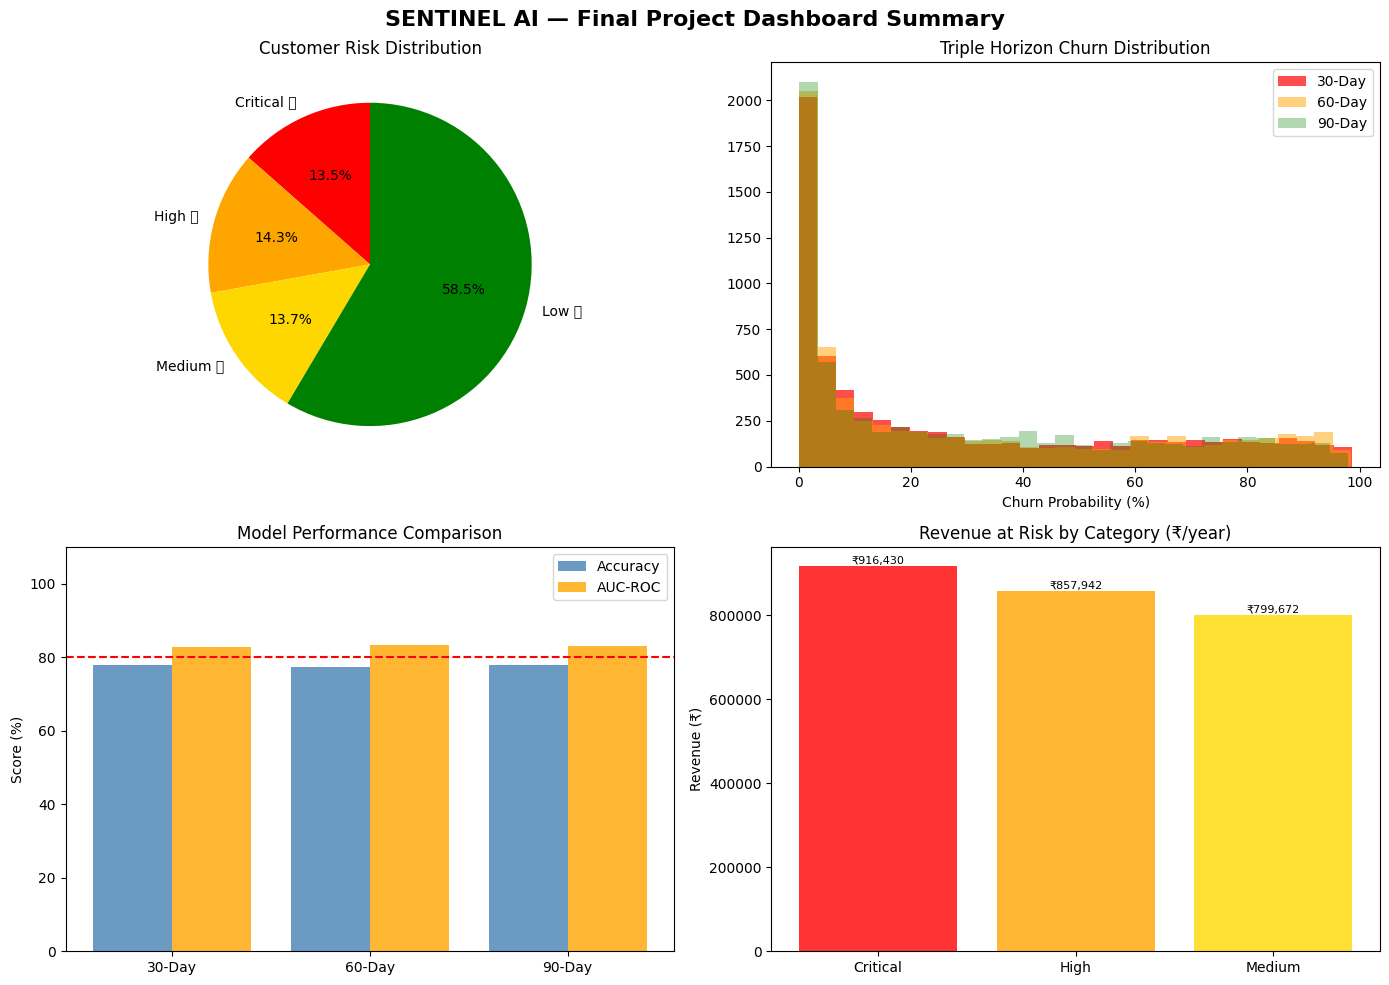

✅ Final summary charts saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SENTINEL AI — Final Project Dashboard Summary',
             fontsize=16, fontweight='bold')

# Chart 1 — Risk distribution pie
risk_data = {
    'Critical 🔴': critical,
    'High 🟠': high,
    'Medium 🟡': medium,
    'Low 🟢': low
}
axes[0,0].pie(
    risk_data.values(),
    labels=risk_data.keys(),
    colors=['red','orange','gold','green'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0,0].set_title('Customer Risk Distribution')

# Chart 2 — Churn probability histogram
axes[0,1].hist(df['churn_prob_30day'], bins=30,
               color='red', alpha=0.7, label='30-Day')
axes[0,1].hist(df['churn_prob_60day'], bins=30,
               color='orange', alpha=0.5, label='60-Day')
axes[0,1].hist(df['churn_prob_90day'], bins=30,
               color='green', alpha=0.3, label='90-Day')
axes[0,1].set_title('Triple Horizon Churn Distribution')
axes[0,1].set_xlabel('Churn Probability (%)')
axes[0,1].legend()

# Chart 3 — Model accuracy comparison
model_names = ['30-Day', '60-Day', '90-Day']
accuracies = []
aucs = []
for model in [m30, m60, m90]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    accuracies.append(accuracy_score(y_test, y_pred)*100)
    aucs.append(roc_auc_score(y_test, y_prob)*100)

x = range(len(model_names))
axes[1,0].bar([i-0.2 for i in x], accuracies, 0.4,
              label='Accuracy', color='steelblue', alpha=0.8)
axes[1,0].bar([i+0.2 for i in x], aucs, 0.4,
              label='AUC-ROC', color='orange', alpha=0.8)
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(model_names)
axes[1,0].set_ylabel('Score (%)')
axes[1,0].set_title('Model Performance Comparison')
axes[1,0].legend()
axes[1,0].set_ylim(0, 110)
axes[1,0].axhline(y=80, color='red', linestyle='--',
                   label='80% threshold')

# Chart 4 — Revenue at risk
if 'MonthlyCharges' in df.columns:
    crit_rev = df[df['churn_prob_30day']>=75]['MonthlyCharges'].sum()*12
    high_rev = df[(df['churn_prob_30day']>=50) &
                  (df['churn_prob_30day']<75)]['MonthlyCharges'].sum()*12
    med_rev  = df[(df['churn_prob_30day']>=25) &
                  (df['churn_prob_30day']<50)]['MonthlyCharges'].sum()*12
    rev_vals = [crit_rev, high_rev, med_rev]
    rev_labels = ['Critical', 'High', 'Medium']
    colors = ['red', 'orange', 'gold']
    bars = axes[1,1].bar(rev_labels, rev_vals,
                          color=colors, alpha=0.8)
    axes[1,1].set_title('Revenue at Risk by Category (₹/year)')
    axes[1,1].set_ylabel('Revenue (₹)')
    for bar, val in zip(bars, rev_vals):
        axes[1,1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'₹{val:,.0f}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs",
            "final_summary_charts.png"), dpi=150)
plt.show()
print("✅ Final summary charts saved!")

In [4]:
print("\n" + "="*60)
print("🏆 SENTINEL AI — COMPLETE PROJECT SUMMARY")
print("="*60)

print("""
📋 PROJECT DETAILS:
   Title    : AI Driven Business Risk Intelligence
   Subtitle : Customer Risk Assessment & Churn Prediction
   Developer: Rakshitha — Final Year B.E CSE, JVIT
   Duration : 12 Weeks Solo Development

🔧 TECH STACK:
   Language : Python 3.14
   ML Models: XGBoost, Random Forest, Scikit-learn
   AI/XAI   : SHAP, LIME
   Dashboard: Streamlit + Plotly
   API      : FastAPI + Uvicorn
   Database : CSV + Processed Data Pipeline
   Deploy   : Streamlit Cloud + GitHub

📊 DATASET:
   Source   : Kaggle — Telco Customer Churn
   Records  : 7,043 customers
   Features : 20+ customer attributes

🤖 ML MODELS:
   30-Day Churn: 77.86% accuracy | 82.69% AUC-ROC
   60-Day Churn: 77.50% accuracy | 83.23% AUC-ROC
   90-Day Churn: 77.86% accuracy | 83.09% AUC-ROC
   Technique   : SMOTE + XGBoost + Feature Engineering

🚀 7 UNIQUE INNOVATIONS:
   1. Multi Dimensional 5D Risk Scoring Engine
   2. Triple Horizon Churn Prediction (30/60/90 days)
   3. Sentiment Fusion with Customer Risk
   4. Explainable AI — SHAP + Auto English Reports
   5. What-If Action Simulator
   6. Revenue at Risk Calculator in ₹
   7. FastAPI Backend with 10 endpoints

📱 DELIVERABLES:
   ✅ Live Dashboard — Streamlit Cloud
   ✅ REST API — FastAPI with Swagger UI
   ✅ 8 Jupyter Notebooks
   ✅ Complete GitHub Repository
   ✅ Project Report
   ✅ PowerPoint Presentation (12 slides)

💰 BUSINESS IMPACT:
   Customers Analyzed  : 7,043
   Critical Risk Found : 952 (13.5%)
   Revenue at Risk     : ₹17,74,373/year
   Potential Saving    : ₹14,19,498/year (80% retention)
""")

print("="*60)
print("🎯 STATUS: READY FOR NATIONAL HACKATHON! 🏆")
print("="*60)


🏆 SENTINEL AI — COMPLETE PROJECT SUMMARY

📋 PROJECT DETAILS:
   Title    : AI Driven Business Risk Intelligence
   Subtitle : Customer Risk Assessment & Churn Prediction
   Developer: Rakshitha — Final Year B.E CSE, JVIT
   Duration : 12 Weeks Solo Development

🔧 TECH STACK:
   Language : Python 3.14
   ML Models: XGBoost, Random Forest, Scikit-learn
   AI/XAI   : SHAP, LIME
   Dashboard: Streamlit + Plotly
   API      : FastAPI + Uvicorn
   Database : CSV + Processed Data Pipeline
   Deploy   : Streamlit Cloud + GitHub

📊 DATASET:
   Source   : Kaggle — Telco Customer Churn
   Records  : 7,043 customers
   Features : 20+ customer attributes

🤖 ML MODELS:
   30-Day Churn: 77.86% accuracy | 82.69% AUC-ROC
   60-Day Churn: 77.50% accuracy | 83.23% AUC-ROC
   90-Day Churn: 77.86% accuracy | 83.09% AUC-ROC
   Technique   : SMOTE + XGBoost + Feature Engineering

🚀 7 UNIQUE INNOVATIONS:
   1. Multi Dimensional 5D Risk Scoring Engine
   2. Triple Horizon Churn Prediction (30/60/90 days)
   3